In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
###############################################################

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [3]:
##################
# Plotting
plotting=False #KEEP FALSE WHEN JOB ARRAY IS RUNNING
plotting=True

In [6]:
profile_TH

array([[0.00000000e+00, 0.00000000e+00, 3.10000014e-02],
       [0.00000000e+00, 0.00000000e+00, 1.08946674e-01],
       [0.00000000e+00, 0.00000000e+00, 2.18786672e-01],
       [0.00000000e+00, 0.00000000e+00, 3.60520035e-01],
       [0.00000000e+00, 0.00000000e+00, 5.34146726e-01],
       [0.00000000e+00, 0.00000000e+00, 7.39666760e-01],
       [0.00000000e+00, 0.00000000e+00, 9.77080107e-01],
       [3.52034161e+04, 1.16000000e+02, 1.24638677e+00],
       [2.72539750e+06, 8.93900000e+03, 1.54758680e+00],
       [5.87997875e+06, 1.91930000e+04, 1.88068032e+00],
       [8.82620873e+06, 2.86590000e+04, 2.24566674e+00],
       [1.17427970e+07, 3.79120000e+04, 2.64254689e+00],
       [1.16422929e+07, 3.73680000e+04, 3.07132053e+00],
       [1.11698911e+07, 3.56380000e+04, 3.53198695e+00],
       [1.10293442e+07, 3.49620000e+04, 4.02454710e+00],
       [1.03538761e+07, 3.25830000e+04, 4.54900074e+00],
       [8.76554167e+06, 2.73380000e+04, 5.10534811e+00],
       [6.93046699e+06, 2.13940

currently on type general
currently on type cloudy


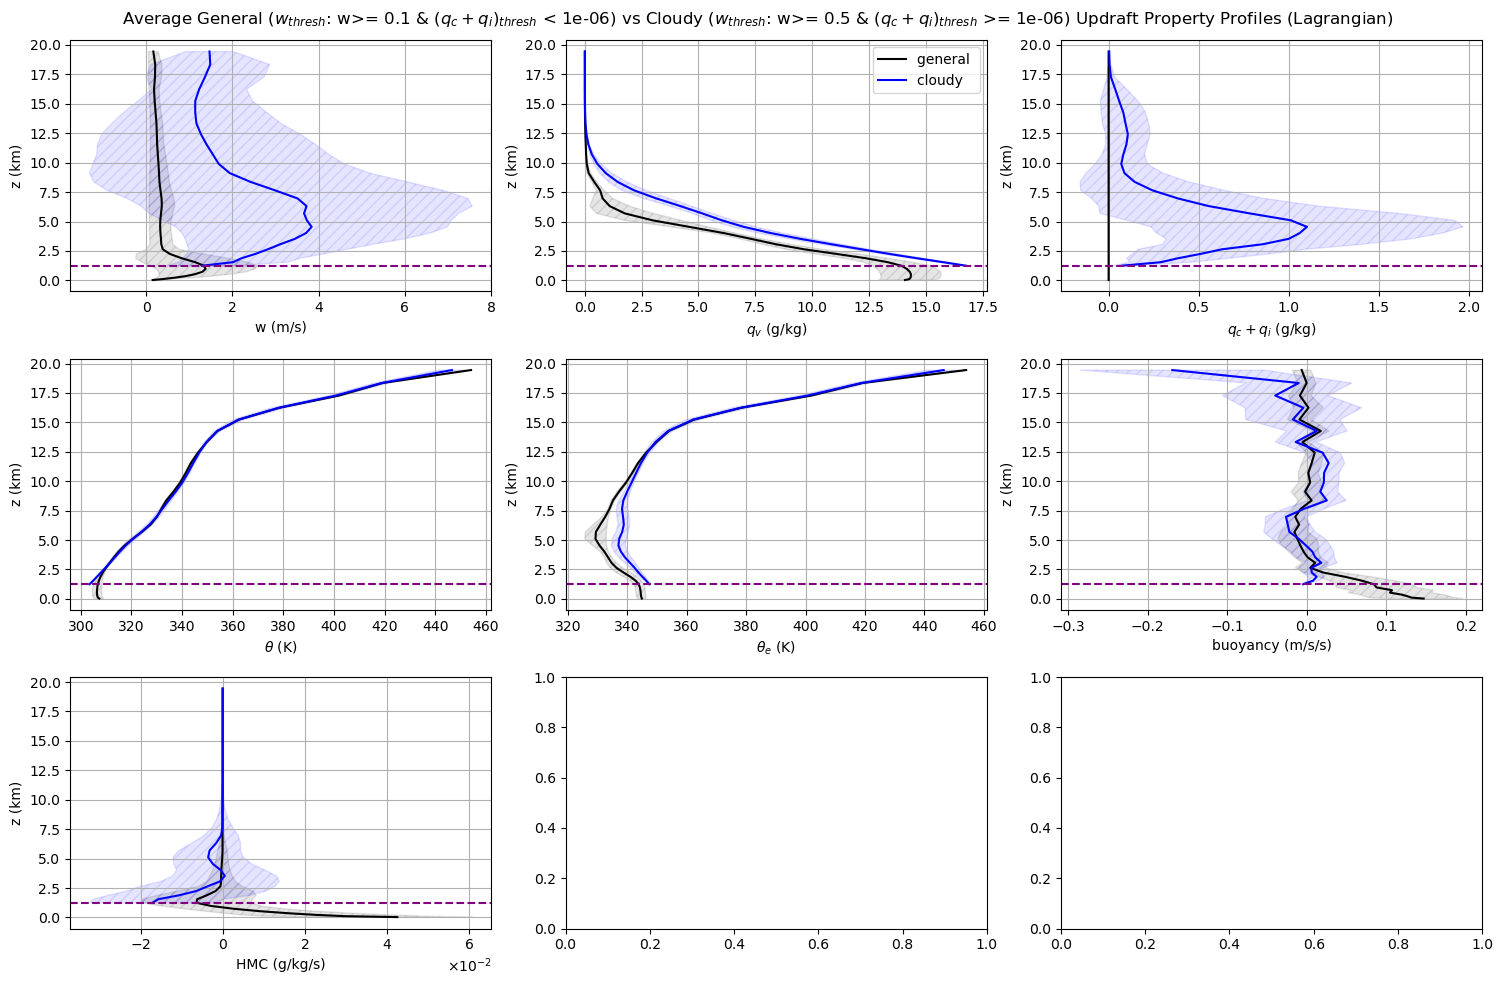

In [17]:
if plotting==True:
        
    #Produced averaged profiles for plotting
    def averaged_profiles(profile):
        out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
        out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
        return out_var
    
    ####################################################################
    res='1km'
    # res='250m'
    label=1
    
    #Uses Plotting Function 
    fig, axs = plt.subplots(3, 3, figsize=(15, 10))
    # if type=='general':
    #     fig.suptitle(f"average lagrangian updraft property profiles") 
    # if type=='cloudy':
    #     fig.suptitle(f"average lagrangian cloudy updraft property profiles")
    fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Profiles (Lagrangian)")
    #CHANGE TITLE IF CTRL CASE IF USING
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()
    # plt.tight_layout()
    
    ####################################################################
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
    
        dir2=dir+'Project_Algorithms/Domain_Profiles/'
        if type == "general":
            input_file = dir2+f'job_out/general_lagrangian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/cloudy_lagrangian_profiles_{res}_{t_res}_{Np_str}.h5' 

        vars=['W','QV','QCQI','TH','TH_E','BUOYANCY', 'HMC']
        with h5py.File(input_file, 'r') as f:
            for var in vars:
                globals()[f"profile_{var}"]=np.array(f[f"profile_{var}"])
                # globals()[f"profile_{var}_SE"]=ProfileStandardError(globals()[f"profile_{var}"],np.array(f[f"profile_{var}_squares"])); factor=1.96
                globals()[f"profile_{var}_SE"]=ProfileStandardDeviation(globals()[f"profile_{var}"],np.array(f[f"profile_{var}_squares"])); factor=1

        
        #Plotting function
        def plotting_func(out_var,axis,label,color):
            axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
            axis.grid(True)
        
        #Uses Averaged_Profiles Function
        for var in vars:
            globals()[f"out_{var}"] = averaged_profiles(globals()[f"profile_{var}"])
        
        vars=['W','QV','QCQI','TH','TH_E','BUOYANCY', 'HMC']
        # vars=['w'] #TESTING
        axises=[ax1,ax2,ax3,ax4,ax5,ax6,ax7] #ax5
        xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)', 'HMC (g/kg/s)'] 
        for var,axis,xlabel in zip(vars,axises,xlabels):
            if type=='general':
                color='k'
            elif type=='cloudy':
                color='blue'

            #converts qv and qc from kg/kg=>g/kg
            if var in ['QV','QCQI','HMC']:
                globals()[f"out_{var}"][:,0]*=1000
                globals()[f"profile_{var}_SE"][:,0]*=1000
                switch=1
            else:
                switch=1

            profile=globals()[f"out_{var}"]
            profile_SE=globals()[f"profile_{var}_SE"]
            plotting_func(profile,axis,label=type+' ',color=color)
            axis.fill_betweenx(profile[:, 1], profile[:, 0] - factor*profile_SE[:,0]*switch, profile[:, 0] + factor*profile_SE[:,0], color=color, alpha=0.10)#,hatch='///')
            axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
    
            if axis==ax2:
                axis.legend(); #add legend
    
            if axis==ax7:
                apply_scientific_notation([axis])
    
    
    #MEAN CLOUD BASE
    qcqi_profile=averaged_profiles(profile_QCQI)
    where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
    cloudbase=qcqi_profile[where_cloudbase,1]
    for axis in axises:
        axis.axhline(cloudbase,color='purple',linestyle='dashed')
    
    
    
    plt.tight_layout()
    #save plot
    # plt.savefig(dir+f'Project_Algorithms/plots/lagrangian_updraft_profiles_{res}_{t_res}_{Np_str}.jpg', bbox_inches='tight', dpi=300)

In [15]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

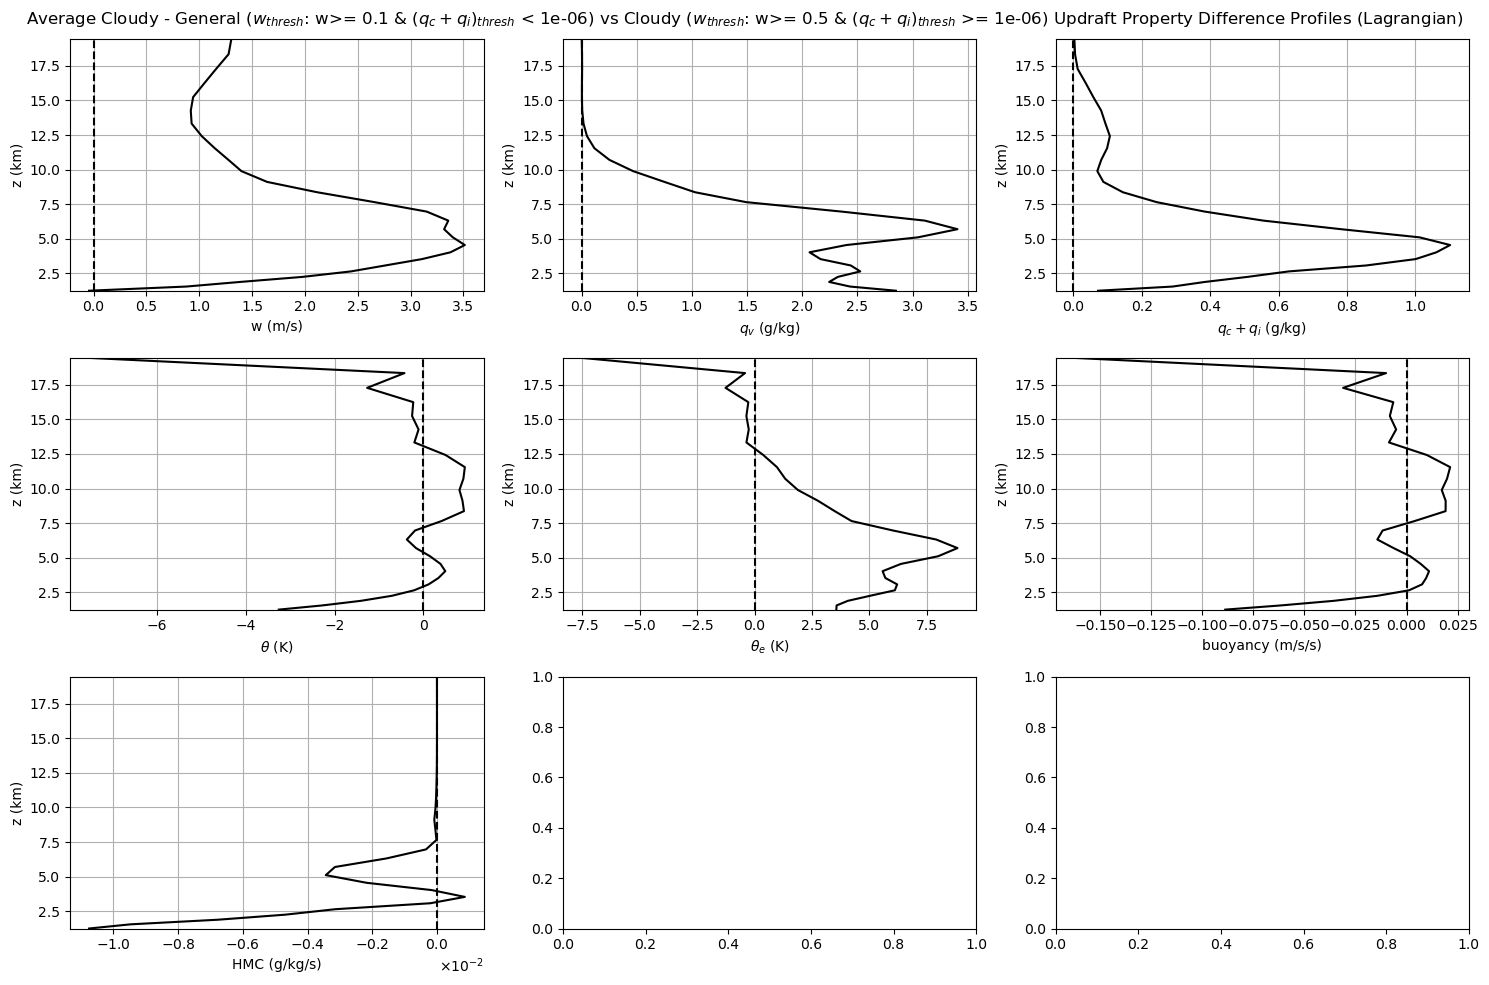

In [16]:
#Plotting Differences
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

def get_data(type):
    if type == "general":
        input_file = dir2+f'job_out/general_lagrangian_profiles_{res}_{t_res}_{Np_str}.h5' 
    elif type == "cloudy":
        input_file = dir2+f'job_out/cloudy_lagrangian_profiles_{res}_{t_res}_{Np_str}.h5'
    
    with h5py.File(input_file, 'r') as f:
        for var in f:
            globals()[f'{type}_{var}'] = f[f'{var}'][:]


    
def diff_plotting():
    #setting up figure
    fig, axs = plt.subplots(3, 3, figsize=(15, 10))
    fig.suptitle(f"Average Cloudy - General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Difference Profiles (Lagrangian)")
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()

    #the plotting
    vars=['W','QV','QCQI','TH','TH_E','BUOYANCY','HMC']
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)','HMC (g/kg/s)'] #qi (g/kg)
    for xlabel,var in zip(xlabels,vars):
        
        if var=='W':axis=ax1
        elif var=='QV':axis=ax2
        elif var=='QCQI':axis=ax3
        elif var=='TH':axis=ax4
        elif var=='TH_E':axis=ax5
        elif var=='BUOYANCY':axis=ax6
        elif var=='HMC':axis=ax7


        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        cutofflow=np.where(out_var_one[:,1]>10)[0][0]
        cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
  
        #averaging
        out_var_diff=average_difference(out_var_one,out_var_two)

        if var in ['QV','QCQI','HMC']:
            out_var_diff[:,0]*=1000
            
        axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k')
        axis.axvline(0,color='k',linestyle='dashed')
        # axis.set_ylim(bottom=0,top=20)
        axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable

        # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING

        if axis==ax7:
            apply_scientific_notation([axis])
    plt.tight_layout()

# #MEAN CLOUD BASE
# for axis in axises:
#     axis.axhline(cloudbase,color='purple',linestyle='dashed')
    plt.savefig(dir+f'Project_Algorithms/plots/lagrangian_updraft_profiles_diff_{res}_{Np_str}test.jpg', bbox_inches='tight', dpi=300) #save plot
diff_plotting() 